# Analyse Exploratoire

### Import des modules

In [1575]:
from warnings import catch_warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Analyse Exploratoire

In [1576]:
data = pd.read_csv('data/raw/2016_Building_Energy_Benchmarking.csv', sep=',')
data.shape

(3376, 46)

In [1577]:
# On regarde comment un batiment est défini dans ce jeu de données 
data.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.000,0659000030,7,DOWNTOWN,47.612,-122.338,1927,1.000,12,88434,0,88434,Hotel,Hotel,88434.000,NaN,NaN,NaN,NaN,NaN,60.000,81.700,84.300,182.500,189.000,7226362.500,7456910.000,2003882.000,1156514.250,3946027.000,12764.529,1276453.000,False,NaN,Compliant,NaN,249.980,2.830
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.000,0659000220,7,DOWNTOWN,47.613,-122.334,1996,1.000,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.000,Parking,15064.000,Restaurant,4622.000,NaN,61.000,94.800,97.900,176.100,179.400,8387933.000,8664479.000,0.000,950425.188,3242851.000,51450.816,5145082.000,False,NaN,Compliant,NaN,295.860,2.860
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.000,0659000475,7,DOWNTOWN,47.614,-122.338,1969,1.000,41,956110,196718,759392,Hotel,Hotel,756493.000,NaN,NaN,NaN,NaN,NaN,43.000,96.000,97.700,241.900,244.100,72587024.000,73937112.000,21566554.000,14515435.000,49526664.000,14938.000,1493800.000,False,NaN,Compliant,NaN,2089.280,2.190
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.000,0659000640,7,DOWNTOWN,47.614,-122.337,1926,1.000,10,61320,0,61320,Hotel,Hotel,61320.000,NaN,NaN,NaN,NaN,NaN,56.000,110.800,113.300,216.200,224.000,6794584.000,6946800.500,2214446.250,811525.312,2768924.000,18112.131,1811213.000,False,NaN,Compliant,NaN,286.430,4.670
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.000,0659000970,7,DOWNTOWN,47.614,-122.340,1980,1.000,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.000,Parking,68009.000,Swimming Pool,0.000,NaN,75.000,114.800,118.700,211.400,215.600,14172606.000,14656503.000,0.000,1573448.625,5368607.000,88039.984,8803998.000,False,NaN,Compliant,NaN,505.010,2.880


In [1578]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [1579]:
# Valeurs unique la colonnes
data.nunique()

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [1580]:
for column in data.columns:
    print(f'Column {column} : {data[column].isnull().sum()} / {data.shape[0]}, soit {data[column].isnull().sum() / data.shape[0] * 100:.2f}%')

Column OSEBuildingID : 0 / 3376, soit 0.00%
Column DataYear : 0 / 3376, soit 0.00%
Column BuildingType : 0 / 3376, soit 0.00%
Column PrimaryPropertyType : 0 / 3376, soit 0.00%
Column PropertyName : 0 / 3376, soit 0.00%
Column Address : 0 / 3376, soit 0.00%
Column City : 0 / 3376, soit 0.00%
Column State : 0 / 3376, soit 0.00%
Column ZipCode : 16 / 3376, soit 0.47%
Column TaxParcelIdentificationNumber : 0 / 3376, soit 0.00%
Column CouncilDistrictCode : 0 / 3376, soit 0.00%
Column Neighborhood : 0 / 3376, soit 0.00%
Column Latitude : 0 / 3376, soit 0.00%
Column Longitude : 0 / 3376, soit 0.00%
Column YearBuilt : 0 / 3376, soit 0.00%
Column NumberofBuildings : 8 / 3376, soit 0.24%
Column NumberofFloors : 0 / 3376, soit 0.00%
Column PropertyGFATotal : 0 / 3376, soit 0.00%
Column PropertyGFAParking : 0 / 3376, soit 0.00%
Column PropertyGFABuilding(s) : 0 / 3376, soit 0.00%
Column ListOfAllPropertyUseTypes : 9 / 3376, soit 0.27%
Column LargestPropertyUseType : 20 / 3376, soit 0.59%
Column La

In [1581]:
for column in data.columns:
    print(f'colonne : {column}')
    print(data[column].unique())
    print('----------')

colonne : OSEBuildingID
[    1     2     3 ... 50224 50225 50226]
----------
colonne : DataYear
[2016]
----------
colonne : BuildingType
<StringArray>
['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)', 'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)', 'Multifamily HR (10+)', 'Nonresidential WA']
Length: 8, dtype: str
----------
colonne : PrimaryPropertyType
<StringArray>
['Hotel', 'Other', 'Mid-Rise Multifamily', 'Mixed Use Property', 'K-12 School', 'University', 'Small- and Mid-Sized Office', 'Self-Storage Facility', 'Warehouse', 'Large Office', 'Senior Care Community', 'Medical Office', 'Retail Store', 'Hospital', 'Residence Hall', 'Distribution Center', 'Worship Facility', 'Low-Rise Multifamily', 'Supermarket / Grocery Store', 'Laboratory', 'Refrigerated Warehouse', 'Restaurant', 'High-Rise Multifamily', 'Office']
Length: 24, dtype: str
----------
colonne : PropertyName
<StringArray>
[               'Mayflower park hotel',                     'Paramount Hotel',   

In [1582]:
data['SiteEnergyUse(kBtu)'].describe()

count        3371.000
mean      5403667.295
std      21610628.628
min             0.000
25%        925128.594
50%       1803753.250
75%       4222455.250
max     873923712.000
Name: SiteEnergyUse(kBtu), dtype: float64

On remarque des outliners au min et au max.

In [1583]:
# Outliner min
outliners_min = data[data['SiteEnergyUse(kBtu)'] == 0]
outliners_min

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
28,34,2016,SPS-District K-12,K-12 School,Meany Building,301/300 21st Ave. E.,Seattle,WA,98112.000,0688000090,3,Central,47.623,-122.305,1955,1.000,1,126351,0,126351,K-12 School,K-12 School,126351.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,False,NaN,Missing Data,NaN,0.000,0.000
31,37,2016,SPS-District K-12,K-12 School,John Hay Elementary,201 Garfield St.,Seattle,WA,98109.000,0809000005,7,MAGNOLIA / QUEEN ANNE,47.633,-122.352,1989,1.000,2,51582,0,51582,K-12 School,K-12 School,55166.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,438691.688,1496816.000,0.000,0.000,False,NaN,Missing Data,NaN,10.430,0.200
62,87,2016,SPS-District K-12,K-12 School,Arbor Heights Elementary,3701 S.W. 104th St.,Seattle,WA,98146.000,2518400005,1,SOUTHWEST,47.510,-122.378,1948,1.000,2,53352,0,53352,K-12 School,K-12 School,65568.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,176088.094,600813.000,0.000,0.000,False,NaN,Missing Data,NaN,4.190,0.080
81,118,2016,SPS-District K-12,K-12 School,Pathfinder K-8,1901 SW Genesee St.,Seattle,WA,98106.000,1324039116,1,DELRIDGE,47.564,-122.358,1999,1.000,3,74468,0,74468,K-12 School,K-12 School,75364.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,497706.812,1698176.000,0.000,0.000,False,NaN,Missing Data,NaN,11.840,0.160
85,122,2016,SPS-District K-12,K-12 School,John Muir Elementary,3301 S. Horton St.,Seattle,WA,98144.000,1524049002,2,SOUTHEAST,47.573,-122.291,1991,1.000,2,58933,0,58933,K-12 School,K-12 School,60725.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,687906.875,2347138.000,0.000,0.000,False,NaN,Missing Data,NaN,16.360,0.280
95,140,2016,SPS-District K-12,K-12 School,B.F. Day Elementary,3921 Linden Ave. N.,Seattle,WA,98103.000,1931301145,6,LAKE UNION,47.655,-122.349,1991,1.000,3,66588,0,66588,K-12 School,K-12 School,66588.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,616730.812,2104286.000,0.000,0.000,False,NaN,Missing Data,NaN,14.670,0.220
133,217,2016,SPS-District K-12,K-12 School,Whitman Middle,9201 15th Ave. NW.,Seattle,WA,98117.000,3526039131,6,BALLARD,47.697,-122.378,1959,1.000,1,160270,0,160270,K-12 School,K-12 School,160270.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,43189.172,4318917.000,False,NaN,Missing Data,NaN,229.380,1.430
139,227,2016,SPS-District K-12,K-12 School,Washington Middle,2101 S. Jackson,Seattle,WA,98144.000,3646100540,3,CENTRAL,47.598,-122.304,1963,1.000,3,136188,0,136188,K-12 School,K-12 School,136188.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,32178.773,3217877.000,False,NaN,Missing Data,NaN,170.900,1.250
152,242,2016,SPS-District K-12,K-12 School,Olympic View Elementary,504 N.E. 95th St.,Seattle,WA,98115.000,5100404840,5,NORTH,47.698,-122.321,1989,1.000,2,52792,0,52792,K-12 School,K-12 School,55480.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,False,NaN,Missing Data,NaN,0.000,0.000
304,435,2016,NonResidential,Other,Washington State Convention Center,705 Pike St,Seattle,WA,98101.000,1978200105,7,DOWNTOWN,47.61

In [1584]:
# Outliners max
outliners_max = data[data['SiteEnergyUse(kBtu)'] == 873923712]
outliners_max.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3274,49967,2016,Campus,University,University of Washington - Seattle Campus,NE 45th St & Brooklyn Ave,Seattle,WA,98105.000,1625049001,4,NORTHEAST,47.656,-122.310,1900,111.000,0,9320156,0,9320156,College/University,College/University,9320156.000,NaN,NaN,NaN,NaN,NaN,NaN,93.800,0.000,246.600,0.000,873923712.000,0.000,84985240.000,192577488.000,657074389.000,0.000,0.000,False,NaN,Compliant,NaN,11140.560,1.200


<Axes: xlabel='Count', ylabel='PrimaryPropertyType'>

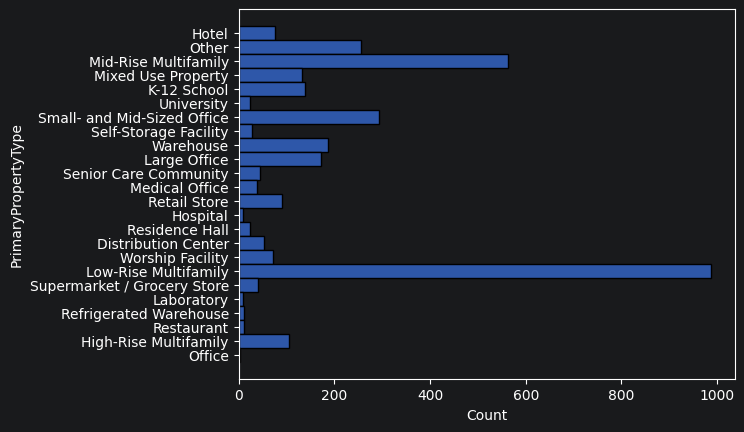

In [1585]:
sns.histplot(data=data, y="PrimaryPropertyType")

On remarque qu'on a des bâtiments destinés à l'habitation dans notre jeu de donnée, et que c'est même une majorité du nombre de batiment du jeu de donnée.

In [1586]:
data.fillna({
    'SiteEnergyUse(kBtu)': 0,
    'NaturalGas(kBtu)': 0,
    'Electricity(kBtu)': 0,
    'SteamUse(kBtu)': 0,
}, inplace=True)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.000,0659000030,7,DOWNTOWN,47.612,-122.338,1927,1.000,12,88434,0,88434,Hotel,Hotel,88434.000,NaN,NaN,NaN,NaN,NaN,60.000,81.700,84.300,182.500,189.000,7226362.500,7456910.000,2003882.000,1156514.250,3946027.000,12764.529,1276453.000,False,NaN,Compliant,NaN,249.980,2.830
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.000,0659000220,7,DOWNTOWN,47.613,-122.334,1996,1.000,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.000,Parking,15064.000,Restaurant,4622.000,NaN,61.000,94.800,97.900,176.100,179.400,8387933.000,8664479.000,0.000,950425.188,3242851.000,51450.816,5145082.000,False,NaN,Compliant,NaN,295.860,2.860
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.000,0659000475,7,DOWNTOWN,47.614,-122.338,1969,1.000,41,956110,196718,759392,Hotel,Hotel,756493.000,NaN,NaN,NaN,NaN,NaN,43.000,96.000,97.700,241.900,244.100,72587024.000,73937112.000,21566554.000,14515435.000,49526664.000,14938.000,1493800.000,False,NaN,Compliant,NaN,2089.280,2.190
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.000,0659000640,7,DOWNTOWN,47.614,-122.337,1926,1.000,10,61320,0,61320,Hotel,Hotel,61320.000,NaN,NaN,NaN,NaN,NaN,56.000,110.800,113.300,216.200,224.000,6794584.000,6946800.500,2214446.250,811525.312,2768924.000,18112.131,1811213.000,False,NaN,Compliant,NaN,286.430,4.670
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.000,0659000970,7,DOWNTOWN,47.614,-122.340,1980,1.000,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.000,Parking,68009.000,Swimming Pool,0.000,NaN,75.000,114.800,118.700,211.400,215.600,14172606.000,14656503.000,0.000,1573448.625,5368607.000,88039.984,8803998.000,False,NaN,Compliant,NaN,505.010,2.880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.567,-122.312,1990,1.000,1,12294,0,12294,Office,Office,12294.000,NaN,NaN,NaN,NaN,NaN,46.000,69.100,76.700,161.700,176.100,849745.688,943003.188,0.000,153655.000,524270.860,3254.750,325475.024,True,NaN,Error - Correct Default Data,NaN,20.940,1.700
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.596,-122.323,2004,1.000,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.000,NaN,NaN,NaN,NaN,NaN,NaN,59.400,65.900,114.200,118.900,950276.188,1053705.750,0.000,116221.000,396546.052,5537.300,553729.980,False,NaN,Compliant,NaN,32.170,2.010
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,7,MAGNOLIA / QUEEN ANNE,47.636,-122.358,1974,1.000,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583.000,Fitness Center/Health Club/Gym,5574.000,Swimming Pool,0.000,NaN,NaN,438.200,460.100,744.800,767.800,5765898.000,6053764.500,0.000,525251.68

Suppression des bâtiments de type habitation

In [1587]:
# Liste des colonnes dans lesquelles on va chercher à retirer les bâtiments résidentiels
to_clean_columns = [
    'BuildingType',
    'PrimaryPropertyType',
    'LargestPropertyUseType',
    'ListOfAllPropertyUseTypes',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType'
]

print(f'Shape avant traitement {data.shape}')
for column in to_clean_columns:
    print(f'Shape avant retrait des bâtiments de type habitation grace a la colonne {column} : {data.shape}')
    data = data[ ~ data[column].str.contains("Multifamily")]
    print(f'Shape avant retrait des bâtiments de type habitation grace a la colonne {column} : {data.shape}')

# Suppression des sites avec une consommation énergétique de 0
print(f'Shape avant traitement des SiteEnergyUse == 0 : {data.shape}')
data = data[ ~ (data['SiteEnergyUse(kBtu)'] == 0)]
print(f'Shape après traitement des SiteEnergyUse == 0 : {data.shape}')

Shape avant traitement (3376, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne BuildingType : (3376, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne BuildingType : (1668, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne PrimaryPropertyType : (1668, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne PrimaryPropertyType : (1665, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne LargestPropertyUseType : (1665, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne LargestPropertyUseType : (1656, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne ListOfAllPropertyUseTypes : (1656, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne ListOfAllPropertyUseTypes : (1629, 46)
Shape avant retrait des bâtiments de type habitation grace a la colonne SecondLargestPropertyUseType : (1629, 46)
Shape av

<Axes: xlabel='Count', ylabel='PrimaryPropertyType'>

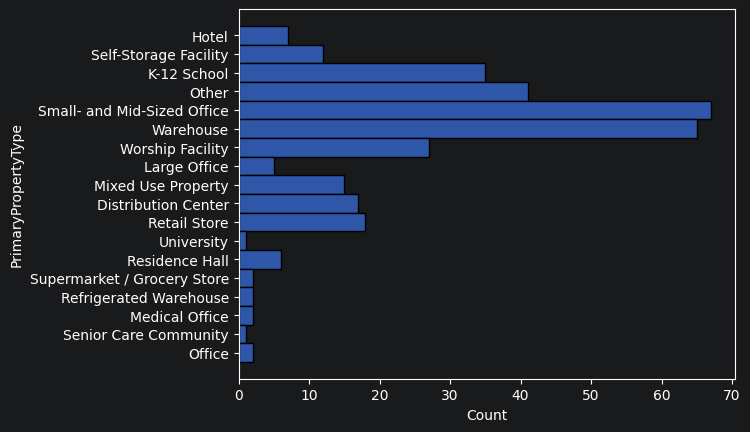

In [1588]:
# Il y a des sites dont le SiteEnergyUse est < SteamUse + Electricity + NaturalGas ce qui est bizarre
strange_consumption_sites = data[data['SiteEnergyUse(kBtu)'] < (data['SteamUse(kBtu)'] + data['Electricity(kBtu)'] + data['NaturalGas(kBtu)'])]
sns.histplot(strange_consumption_sites, y='PrimaryPropertyType')

In [1589]:
# Calcule du poucentage de différence entre SteamUse + Electricity + NaturalGas et SiteEnergyUse
data['delta'] = data['SiteEnergyUse(kBtu)'] - (data['SteamUse(kBtu)'] + data['Electricity(kBtu)'] + data['NaturalGas(kBtu)'])
data['delta_percentage'] = (100 * data['delta']) / data['SiteEnergyUse(kBtu)']

# Sont considérés comme incohérent les bâtiments dont la consommation totale est plus faible que la somme de la consommation électrique + gas + vapeur
incoherent_consumption_sites = data[data['delta'] < 0]
incoherent_consumption_sites['delta'].describe()

count        325.000
mean       -6574.827
std        73399.973
min     -1109896.500
25%           -0.375
50%           -0.250
75%           -0.188
max           -0.069
Name: delta, dtype: float64

In [1590]:
# On retire tous les batiments qui ont un écart de consommation de plus de 1%
print(f'Shape avant traitement des SiteEnergyUse == 0 : {data.shape}')
data = data[ ~ (abs(data['delta_percentage']) > 1)]
print(f'Shape après traitement des SiteEnergyUse == 0 : {data.shape}')

Shape avant traitement des SiteEnergyUse == 0 : (1611, 48)
Shape après traitement des SiteEnergyUse == 0 : (1588, 48)


<Axes: xlabel='SiteEnergyUse(kBtu)'>

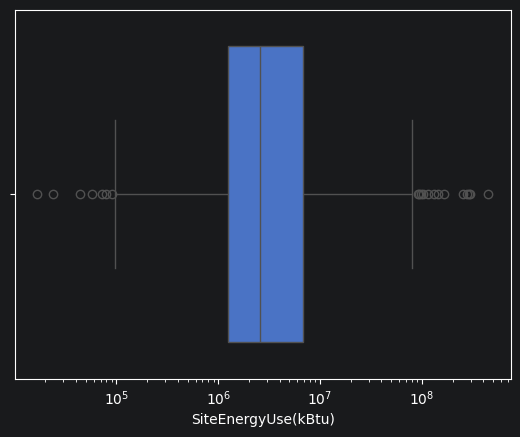

In [1591]:
sns.boxplot(data=data['SiteEnergyUse(kBtu)'], orient='h', log_scale=True)

Text(0.5, 4.844444444444436, 'Consommation en kBtu - Echelle log')

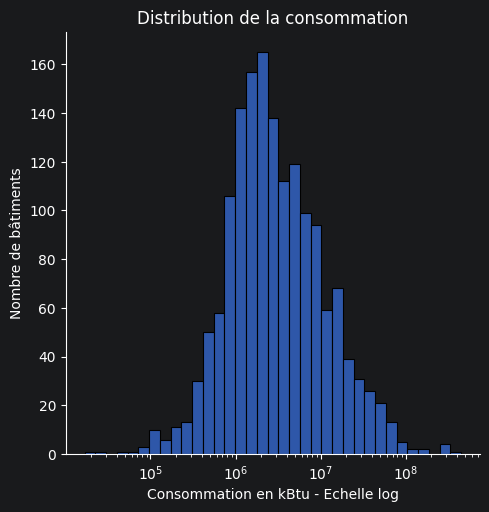

In [1592]:
sns.displot(data['SiteEnergyUse(kBtu)'], log_scale=True)

plt.title('Distribution de la consommation')
plt.ylabel('Nombre de bâtiments')
plt.xlabel('Consommation en kBtu - Echelle log')

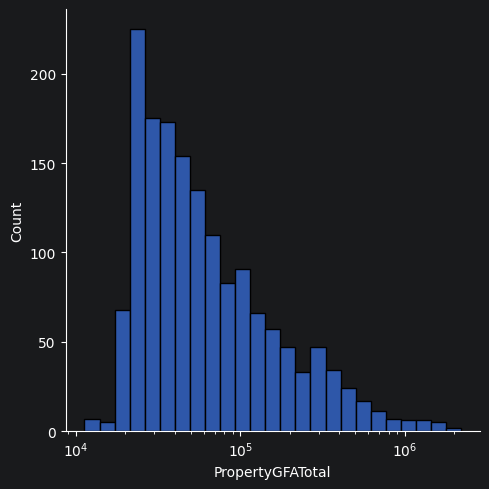

In [1593]:
sns.displot(data['PropertyGFATotal'], log_scale=True)

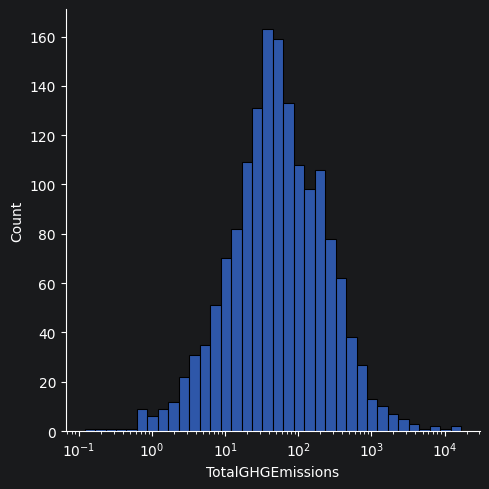

In [1594]:
sns.displot(data['TotalGHGEmissions'], log_scale=True)

Text(0, 0.5, 'Surface du batiment en sqft')

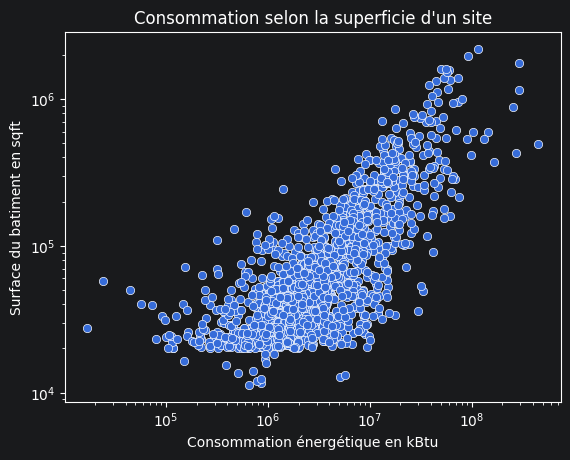

In [1595]:
# Voyons comment évolue la consommation en fonction de la surface du site
plt.xscale('log')
plt.yscale('log')
sns.scatterplot(x=data['SiteEnergyUse(kBtu)'], y=data['PropertyGFATotal'])

plt.title('Consommation selon la superficie d\'un site')
plt.xlabel('Consommation énergétique en kBtu')
plt.ylabel('Surface du batiment en sqft')

Text(0, 0.5, 'Surface des bâtiments en sqft')

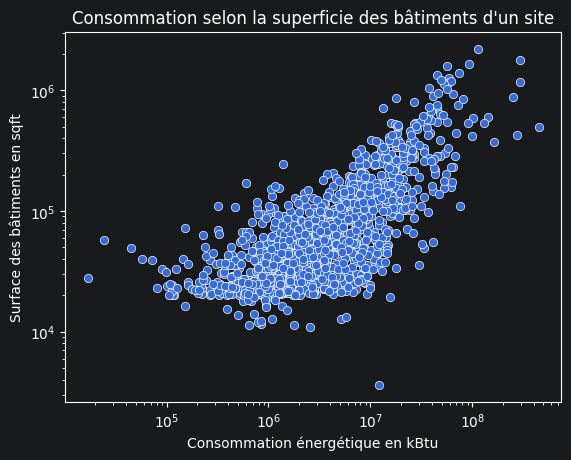

In [1596]:
# Voyons comment évolue la consommation en fonction de la surface du batiment
plt.xscale('log')
plt.yscale('log')
sns.scatterplot(x=data['SiteEnergyUse(kBtu)'], y=data['PropertyGFABuilding(s)'])

plt.title('Consommation selon la superficie des bâtiments d\'un site')
plt.xlabel('Consommation énergétique en kBtu')
plt.ylabel('Surface des bâtiments en sqft')

Text(0, 0.5, 'Surface des parking en sqft -  Echelle log')

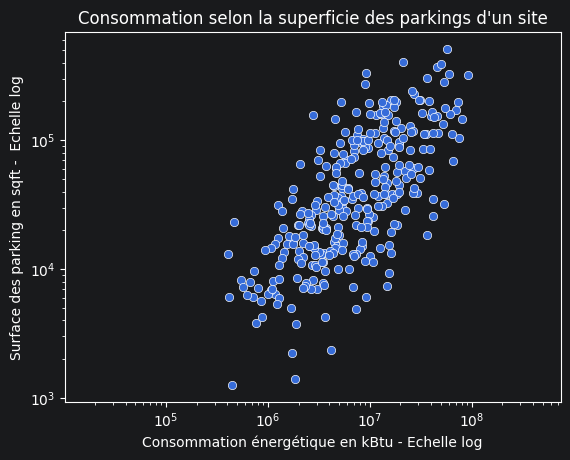

In [1597]:
# Voyons comment évolue la consommation en fonction de la surface du parking
plt.xscale('log')
plt.yscale('log')
sns.scatterplot(x=data['SiteEnergyUse(kBtu)'], y=data['PropertyGFAParking'])

plt.title('Consommation selon la superficie des parkings d\'un site')
plt.xlabel('Consommation énergétique en kBtu - Echelle log')
plt.ylabel('Surface des parking en sqft -  Echelle log')

Text(0, 0.5, 'Quartier')

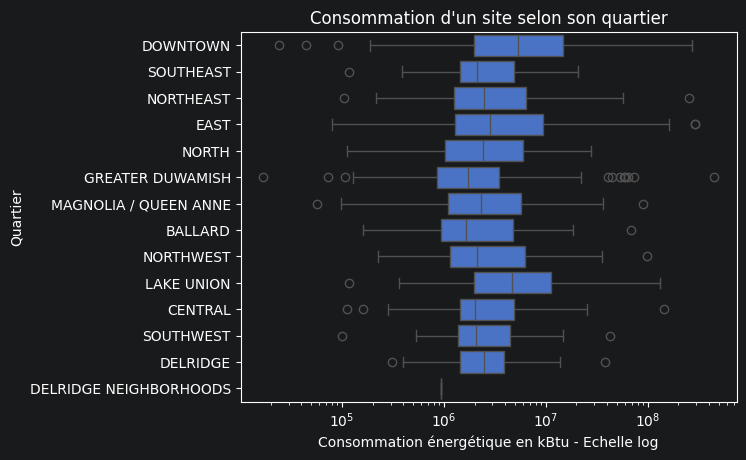

In [1615]:
# Voyons comment évolue la consommation en fonction du quartier
data['Neighborhood'] = data['Neighborhood'].str.upper().str.strip()

plt.xscale('log')
sns.boxplot(x=data['SiteEnergyUse(kBtu)'], y=data['Neighborhood'])
plt.title('Consommation d\'un site selon son quartier')
plt.xlabel('Consommation énergétique en kBtu - Echelle log')
plt.ylabel('Quartier')

<Axes: xlabel='SiteEnergyUse(kBtu)', ylabel='BuildingType'>

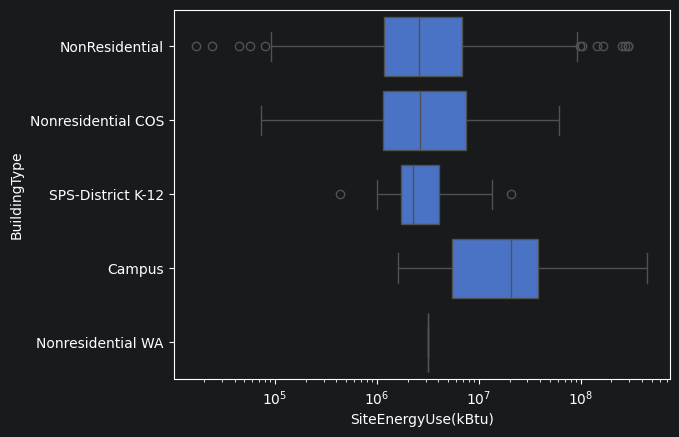

In [1599]:
plt.xscale('log')
sns.boxplot(x=data['SiteEnergyUse(kBtu)'], y=data['BuildingType'])

Text(0, 0.5, "Type d'utilisation")

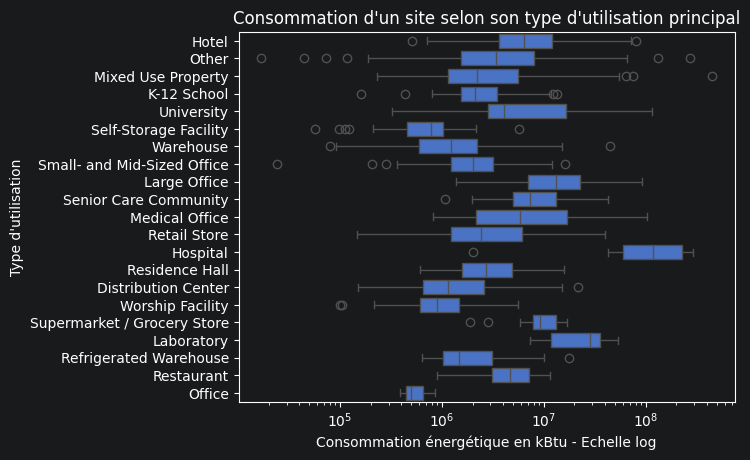

In [1600]:
plt.xscale('log')
sns.boxplot(x=data['SiteEnergyUse(kBtu)'], y=data['PrimaryPropertyType'])

plt.title('Consommation d\'un site selon son type d\'utilisation principal')
plt.xlabel('Consommation énergétique en kBtu - Echelle log')
plt.ylabel('Type d\'utilisation')

Text(0.5, 0, 'Année de construction')

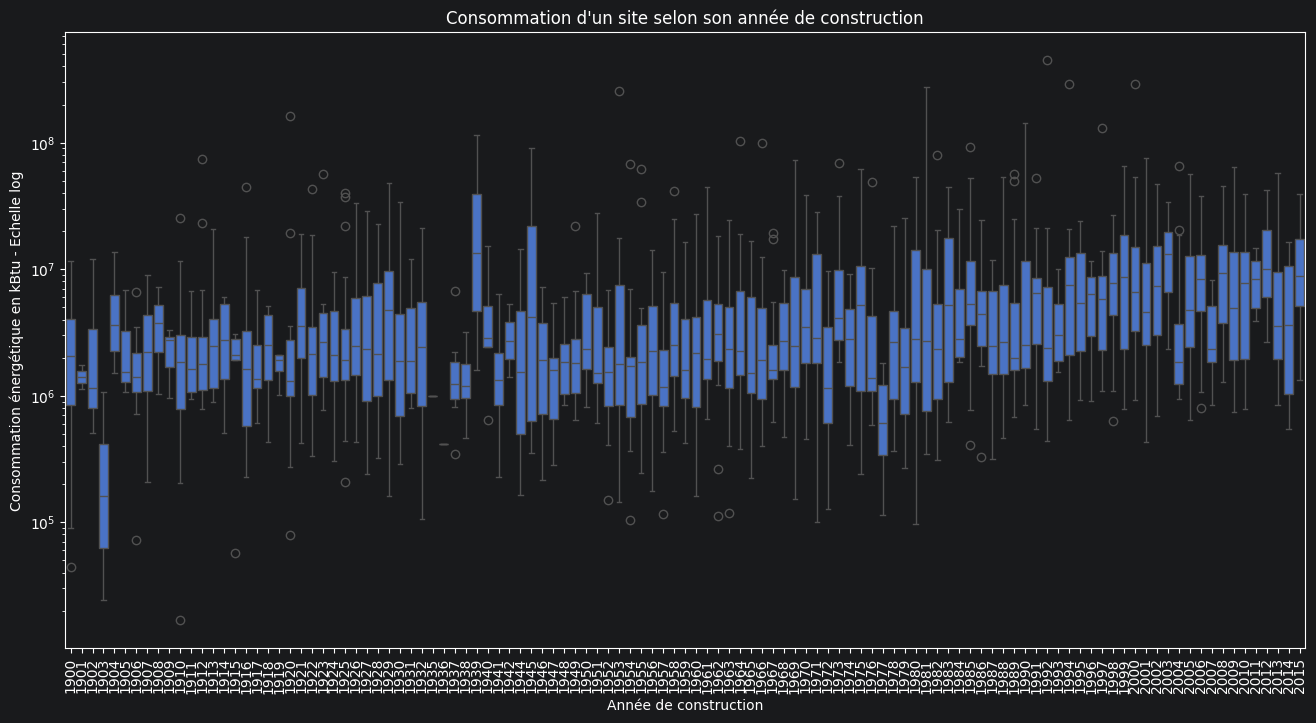

In [1601]:
var = 'YearBuilt'
data_boxplot_energy_yearbuilt = pd.concat([data['SiteEnergyUse(kBtu)'], data[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 8))
fig = sns.boxplot(x=var, y="SiteEnergyUse(kBtu)", data=data_boxplot_energy_yearbuilt, log_scale=True)
plt.xticks(rotation=90);

plt.title('Consommation d\'un site selon son année de construction')
plt.ylabel('Consommation énergétique en kBtu - Echelle log')
plt.xlabel('Année de construction')

<Axes: xlabel='YearBuilt', ylabel='SiteEnergyUse(kBtu)'>

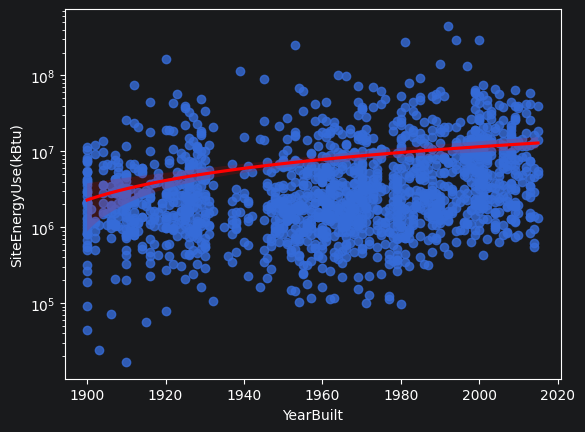

In [1602]:
plt.yscale('log')
sns.regplot(
    x=data['YearBuilt'],
    y=data['SiteEnergyUse(kBtu)'],
    line_kws={"color": "red"}
)

Text(0.5, 0, "Total d'émission de gaz à effet de serre")

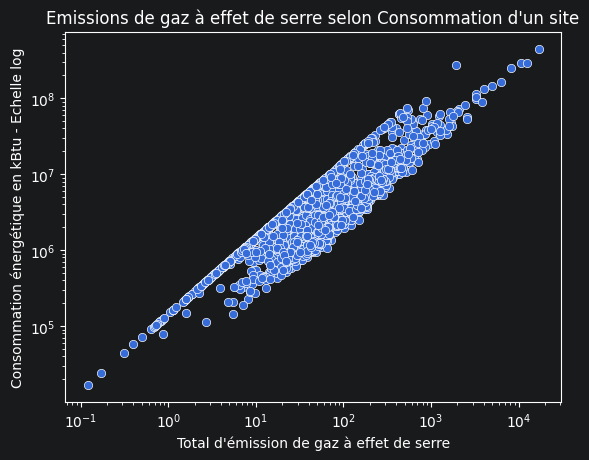

In [1603]:
plt.yscale('log')
plt.xscale('log')
sns.scatterplot(x=data['TotalGHGEmissions'], y=data['SiteEnergyUse(kBtu)'])

plt.title('Emissions de gaz à effet de serre selon Consommation d\'un site')
plt.ylabel('Consommation énergétique en kBtu - Echelle log')
plt.xlabel('Total d\'émission de gaz à effet de serre')

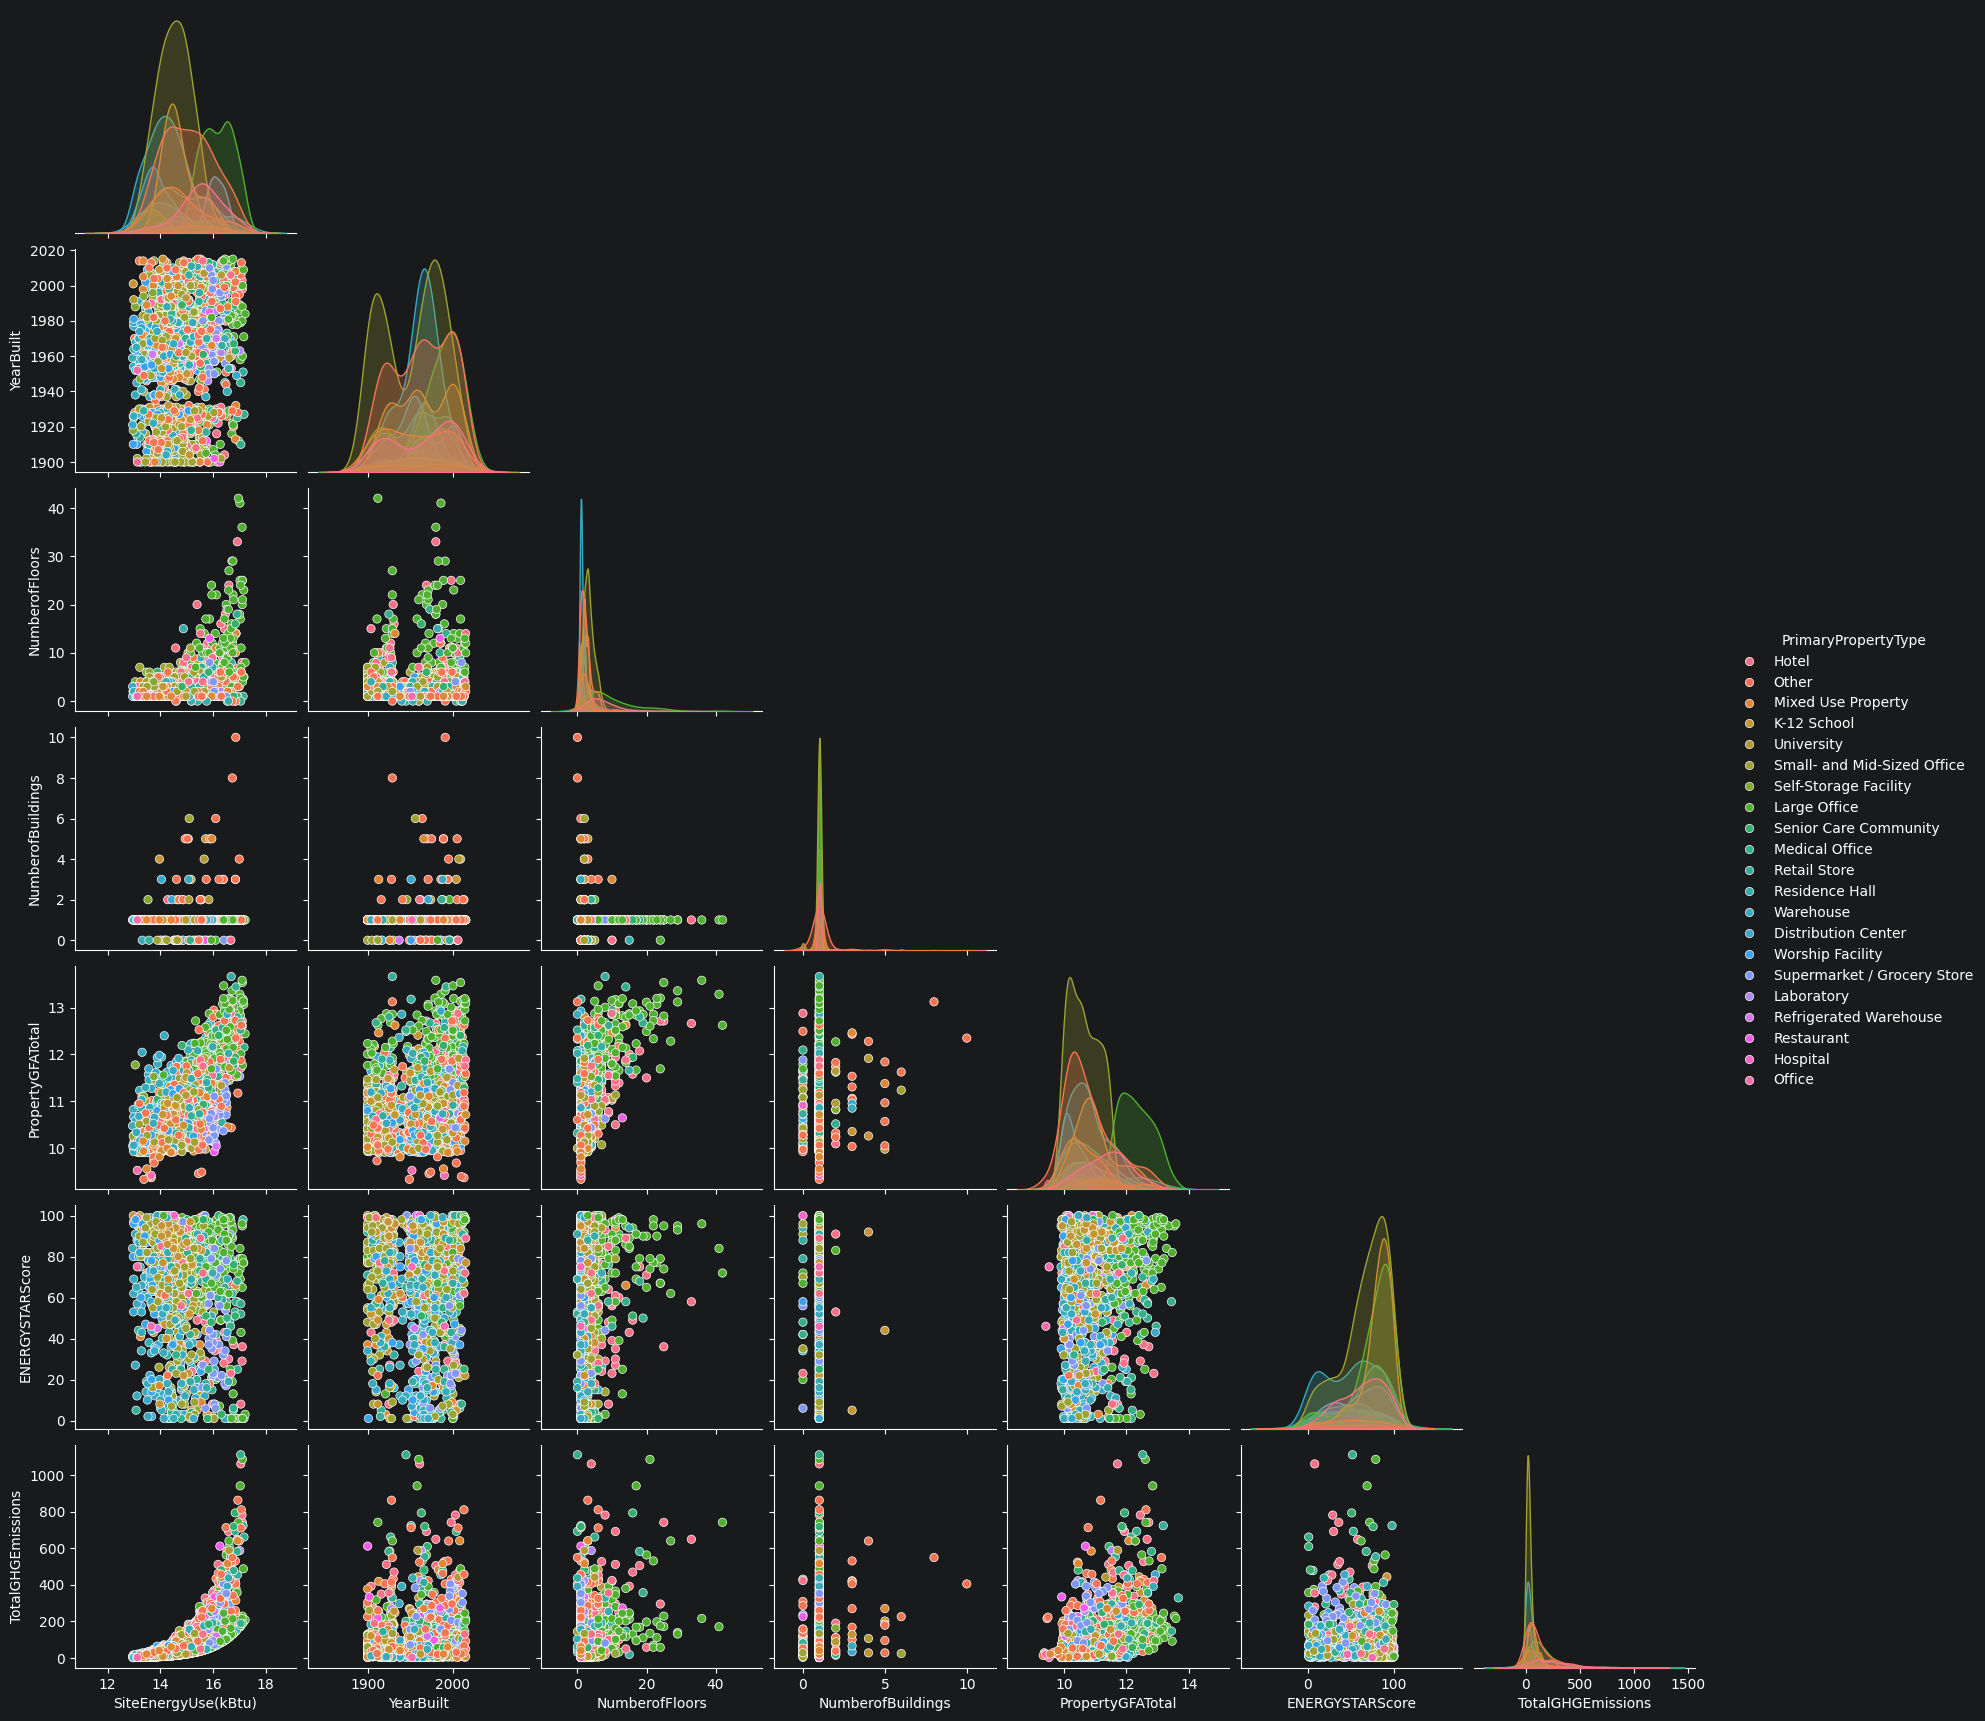

In [1604]:
import numpy as np

# On retire les outliers pour simplifier la visualisation
outliers_max_value = data["SiteEnergyUse(kBtu)"].quantile(0.95)
outliers_min_value = data["SiteEnergyUse(kBtu)"].quantile(0.05)

data_without_outliers = data[(data['SiteEnergyUse(kBtu)'] > outliers_min_value) & (data['SiteEnergyUse(kBtu)'] < outliers_max_value)]

cols = ['SiteEnergyUse(kBtu)', 'BuildingType', 'PrimaryPropertyType', 'YearBuilt', 'NumberofFloors', 'NumberofBuildings', 'PropertyGFATotal', 'ENERGYSTARScore', 'TotalGHGEmissions']

data_without_outliers = data_without_outliers[cols]
data_without_outliers['SiteEnergyUse(kBtu)'] = np.log1p(data_without_outliers['SiteEnergyUse(kBtu)'])
data_without_outliers['PropertyGFATotal'] = np.log1p(data_without_outliers['PropertyGFATotal'])

sns.pairplot(data_without_outliers, hue='PrimaryPropertyType', corner=True)

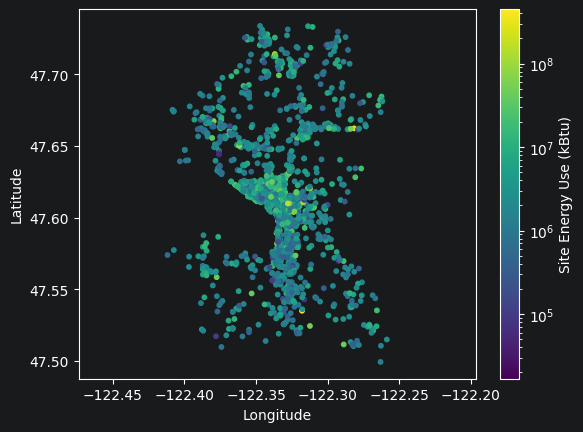

In [1614]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

sc = plt.scatter(
    data['Longitude'],
    data['Latitude'],
    c=data['SiteEnergyUse(kBtu)'],
    cmap='viridis',
    norm=colors.LogNorm(vmin=data['SiteEnergyUse(kBtu)'].min(), vmax=data['SiteEnergyUse(kBtu)'].max()),
    s=10
)

plt.axis('equal')

plt.colorbar(sc, label='Site Energy Use (kBtu)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Text(0, 0.5, 'Latitude')

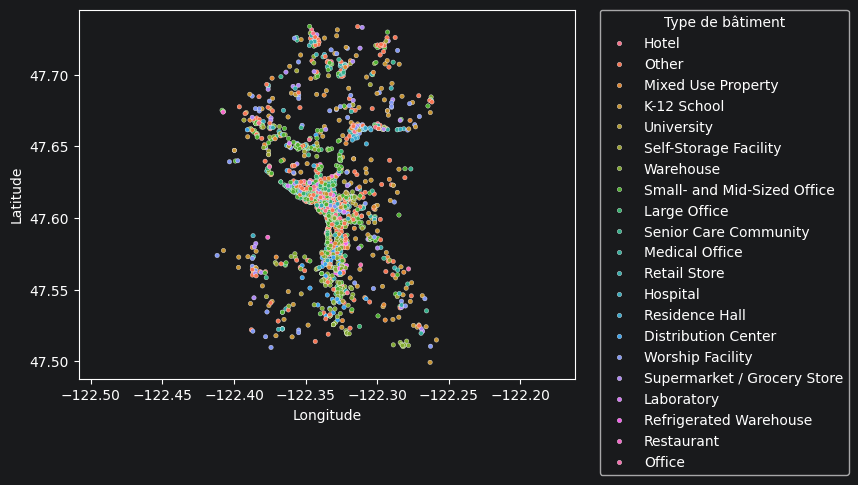

In [1613]:
sns.scatterplot(
    x=data['Longitude'],
    y=data['Latitude'],
    hue=data['PrimaryPropertyType'],
    s=10,
)

plt.axis('equal')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title="Type de bâtiment")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

Text(0, 0.5, 'Latitude')

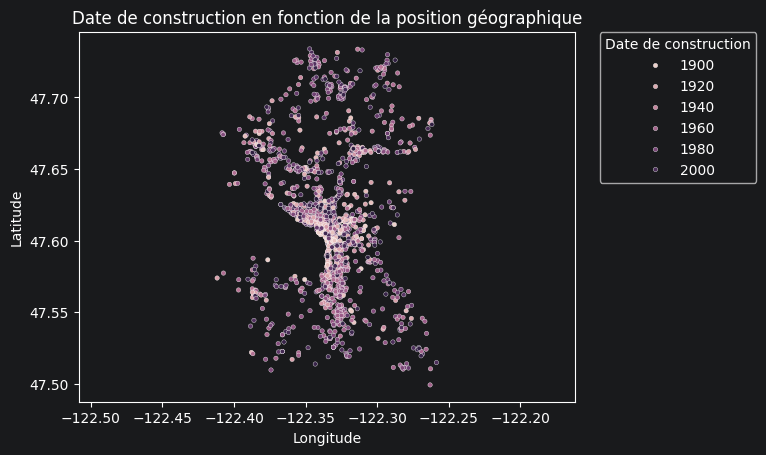

In [1607]:
sns.scatterplot(
    x=data['Longitude'],
    y=data['Latitude'],
    hue=data['YearBuilt'],
    s=10
)


plt.axis('equal')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title="Date de construction")

plt.title('Date de construction en fonction de la position géographique')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [1608]:
data['number_of_activities'] = data['ListOfAllPropertyUseTypes'].fillna('').apply(
    lambda x: len(x.split(',')) if x != '' else 0
)

In [1609]:
monoactivity_sites = data[data['number_of_activities'] == 1]
multiactivity_sites = data[data['number_of_activities'] > 1]

print(monoactivity_sites.shape)
print(multiactivity_sites.shape)

(779, 49)
(809, 49)


Text(0.5, 0, "Nombre d'activités différentes")

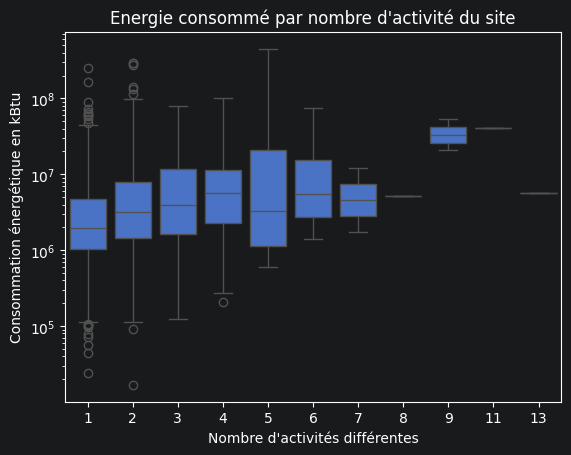

In [1610]:
plt.yscale('log')
sns.boxplot(y=data['SiteEnergyUse(kBtu)'], x=data['number_of_activities'])

plt.title('Energie consommé par nombre d\'activité du site')
plt.ylabel('Consommation énergétique en kBtu')
plt.xlabel('Nombre d\'activités différentes')

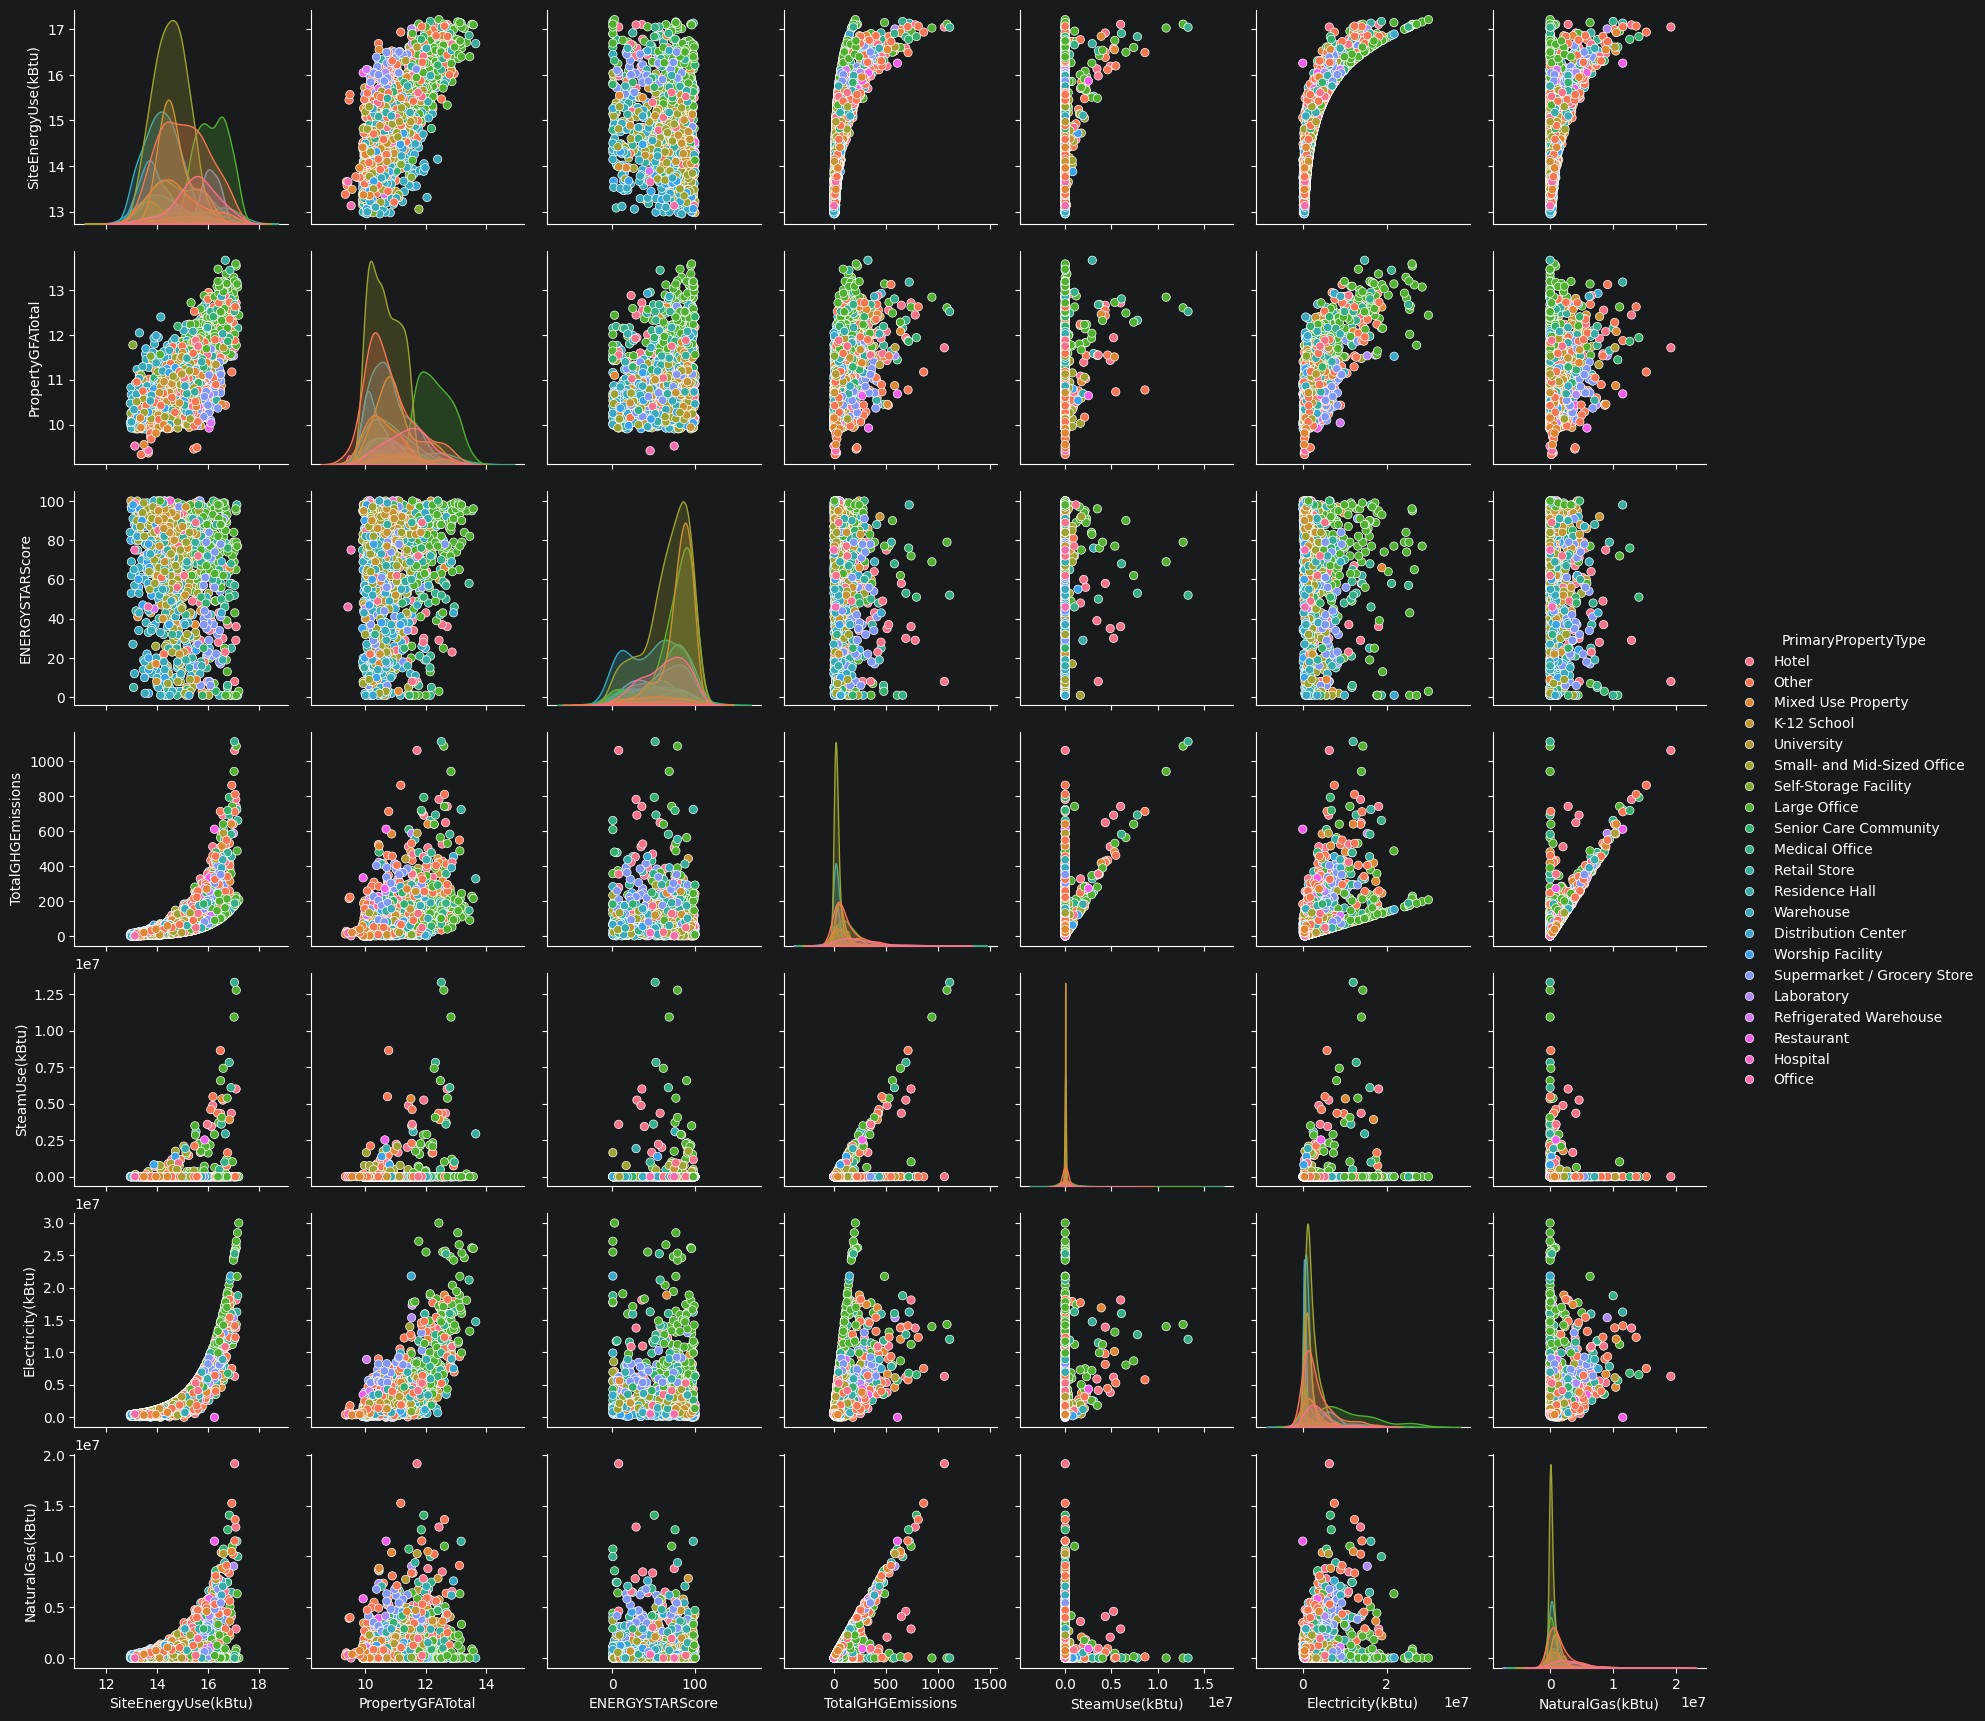

In [1611]:
# On regarde si la méthode d'approvisionnement en énergie influe sur le bilan de gas à effet de serre

# On retire les outliers car sinon les graphiques sont trop écrasés
outliers_max_value = data["SiteEnergyUse(kBtu)"].quantile(0.95)
outliers_min_value = data["SiteEnergyUse(kBtu)"].quantile(0.05)

data_without_outliers = data[(data['SiteEnergyUse(kBtu)'] > outliers_min_value) & (data['SiteEnergyUse(kBtu)'] < outliers_max_value)]

cols = ['SiteEnergyUse(kBtu)', 'PropertyGFATotal', 'ENERGYSTARScore', 'TotalGHGEmissions', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'PrimaryPropertyType']

data_without_outliers = data_without_outliers[cols]
data_without_outliers['SiteEnergyUse(kBtu)'] = np.log1p(data_without_outliers['SiteEnergyUse(kBtu)'])
data_without_outliers['PropertyGFATotal'] = np.log1p(data_without_outliers['PropertyGFATotal'])

sns.pairplot(data_without_outliers, hue='PrimaryPropertyType')

# Résultats de l'analyse

- La surface totale a une influence sur consommation totale
- Le secteur d'activité a une influence sur la consommation
- Le quartier dans une moindre mesure a une influence sur la consommation
- La consommation a une influence sur les émissions de gaz à effet de serre
- Le nombre d'activités différentes dans un bâtiment influe sur la consommation
- Le type principal d'approvisionnement en énergie influe sur les émissions de gaz à effet de serre

## Choix de la target principale

Parmi la liste des indicateurs intéressants suivants :
- **Latitude**
- **Longitude**
- **Neighborhood** : Zone de voisinage définie par le département des quartiers de la ville de Seattle
- **BuildingType** : Classification des types de bâtiments de haut niveau de la ville de Seattle
- **YearBuilt** : Année de construction du bien
- **NumberofFloors** : Nombre d'étages habitables au niveau du sol ou au-dessus.
- **NumberofBuildings** : Nombre de bâtiments faisant partie de chaque propriété
- **PropertyGFATotal** : Surface brute totale du bâtiment et du parking.
- **PropertyGFABuildings** : Surface totale de plancher en pieds carrés entre les surfaces extérieures des murs d'enceinte d'un bâtiment.
- **PropertyGFAParking** : Surface totale en pieds carrés de tous les types de stationnement
- **ENERGYSTARScore** : L'EPA attribue une note de 1 à 100 qui évalue la performance énergétique globale d'un bâtiment, sur la base de données nationales permettant de neutraliser les différences liées au climat, à l'usage du bâtiment et à son exploitation. Un score de 50 représente la médiane nationale.
- **SiteEUI**(kBtu/sf) : consommation énergétique du site d'un bâtiment divisée par sa surface de plancher brute.
- **SiteEnergyUse**(kBtu) : La quantité annuelle d'énergie consommée par la propriété, toutes sources d'énergie confondues.
- **LargestPropertyUseType** : Le type d'utilisation du bien le plus important en fonction de la surface de plancher brute du bâtiment (soit en pieds carrés).
- **LargestPropertyUseTypeGFA** : La surface brute de plancher en pieds carrés, du type d'utilisation de la propriété le plus important
- **SecondLargestPropertyUseType** : Le deuxième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment (c.-à-d. la superficie en pieds carrés), le cas échéant.
- **SecondLargestPropertyUseTypeGFA** : La superficie brute de plancher en pieds carrés, du deuxième type d'utilisation de la propriété le plus important, le cas échéant
- **ThirdLargestPropertyUseType** : Le troisième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment (c.-à-d. la superficie en pieds carrés), le cas échéant.
- **ThirdLargestPropertyUseTypeGFA** : La superficie brute de plancher en pieds carrés du troisième type d'utilisation de la propriété le plus important, le cas échéant.
- **TotalGHGEmissions** : La quantité totale d'émissions de gaz à effet de serre
- **GHGEmissionsIntensity** : Émissions totales de gaz à effet de serre divisées par la surface brute de plancher de la propriété

L'indicateur principal choisi sera SiteEnergyUse(kBtu), steam, electricity et natural gas sont intéressants, mais c'est la consommation générale d'un bâtiment cumulé qu'il nous faut donc électricité, vapeur et gaz naturel cumulé.

Notre target cible sera donc **SiteEnergyUse(kBtu)**

In [1612]:
import os

if not os.path.exists('./data/interim/'):
    os.mkdir('./data/interim/')

data.to_csv('./data/interim/2016_Building_Energy_Benchmarking.csv', index=False)